# Salt River: Uncertainties in Future Reservoir Change Predictions

In [9]:
from datetime import datetime
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

rs = 123 #Fix random state
uf = 60.3/1000 #Conversion factor from cu ft/s to 1000 acre-feet per 30 days

#Individual prediction uncertainties, copied and hard-coded
salt_up_err = 0.19
salt_down_err = 0.51

The following is redundant code to generate the future upstream and downstream flow predictions

In [10]:
df = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
season_length = 12
test_size = int(8.5 * season_length) # Set aside the last 8.5 years as our ultimate testing set.
df_train = df[:-test_size]
df_test = df[-test_size:]
salt_upstream_features = [
    "Temp_Salt",
    "Precip_Salt",
    "log_flow_salt_upstream_lag_1",
    "log_flow_salt_upstream_lag_12"
]

target = "log_flow_salt_upstream"
all_cols_needed = salt_upstream_features + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

salt_upstream_model = RandomForestRegressor(max_depth=10, n_estimators=300, random_state=rs)
salt_upstream_model.fit(df_model_train[salt_upstream_features], df_model_train[target])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [11]:
salt_downstream_features = [
    "Temp_Salt",
    "Precip_Salt",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_salt_upstream",
    "log_flow_salt_downstream_lag_9",
    "log_flow_salt_downstream_lag_12"
]

target = "log_flow_salt_downstream"
all_cols_needed = salt_downstream_features + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

salt_downstream_model = RandomForestRegressor(max_depth=6, n_estimators=100, random_state=rs)
salt_downstream_model.fit(df_model_train[salt_downstream_features], df_model_train[target])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [12]:

# Load historical and future data sets
df_history = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
df_future_245 = pd.read_csv("../Data/FormattedData/FutureVals_SSP245Climate_and_AllOtherFeatures.csv").head(120) #Keep only 10 years for future predictions
df_future_585 = pd.read_csv("../Data/FormattedData/FutureVals_SSP585Climate_and_AllOtherFeatures.csv").head(120)

# Define the columns we want to keep from the historical data
extra_historical_targets = ["log_flow_salt_upstream","log_flow_salt_downstream"]
history_columns_to_keep = list(df_future_245.columns) + extra_historical_targets

# Extract the top 5 rows with the designated features
df_history_top5 = df_history.tail(5)[history_columns_to_keep].copy()

# Combine historical and pojected future data vertically
# Note: Pandas automatically pads the future rows with NaN under the target columns
df_combined_245 = pd.concat([df_history_top5, df_future_245], axis=0).reset_index(drop=True)
df_combined_585 = pd.concat([df_history_top5, df_future_585], axis=0).reset_index(drop=True)

# Create lag columns
df_combined_245["log_flow_salt_upstream_lag_1"] = df_combined_245["log_flow_salt_upstream"].shift(1)
df_combined_245["log_flow_salt_upstream_lag_12"] = df_combined_245["log_flow_salt_upstream"].shift(12)
df_combined_245["log_flow_salt_downstream_lag_9"] = df_combined_245["log_flow_salt_downstream"].shift(9)
df_combined_245["log_flow_salt_downstream_lag_12"] = df_combined_245["log_flow_salt_downstream"].shift(12)

df_combined_585["log_flow_salt_upstream_lag_1"] = df_combined_585["log_flow_salt_upstream"].shift(1)
df_combined_585["log_flow_salt_upstream_lag_12"] = df_combined_585["log_flow_salt_upstream"].shift(12)
df_combined_585["log_flow_salt_downstream_lag_9"] = df_combined_585["log_flow_salt_downstream"].shift(9)
df_combined_585["log_flow_salt_downstream_lag_12"] = df_combined_585["log_flow_salt_downstream"].shift(12)

In [13]:

for i in range(12,len(df_combined_245.Time)):
    df_combined_245.loc[i,'log_flow_salt_upstream_lag_1'] = df_combined_245.loc[i-1,'log_flow_salt_upstream']
    df_combined_245.loc[i,'log_flow_salt_upstream_lag_12'] = df_combined_245.loc[i-11,'log_flow_salt_upstream']
    df_combined_245.loc[i,'log_flow_salt_upstream'] = salt_upstream_model.predict(df_combined_245[salt_upstream_features].iloc[[i]])[0]
    
    df_combined_245.loc[i,'log_flow_salt_downstream_lag_9'] = df_combined_245.loc[i-5,'log_flow_salt_downstream']
    df_combined_245.loc[i,'log_flow_salt_downstream_lag_12'] = df_combined_245.loc[i-6,'log_flow_salt_downstream']
    df_combined_245.loc[i,'log_flow_salt_downstream'] = salt_downstream_model.predict(df_combined_245[salt_downstream_features].iloc[[i]])[0]
    
for i in range(12,len(df_combined_585.Time)):
    df_combined_585.loc[i,'log_flow_salt_upstream_lag_1'] = df_combined_585.loc[i-1,'log_flow_salt_upstream']
    df_combined_585.loc[i,'log_flow_salt_upstream_lag_12'] = df_combined_585.loc[i-11,'log_flow_salt_upstream']
    df_combined_585.loc[i,'log_flow_salt_upstream'] = salt_upstream_model.predict(df_combined_585[salt_upstream_features].iloc[[i]])[0]
    
    df_combined_585.loc[i,'log_flow_salt_downstream_lag_9'] = df_combined_585.loc[i-5,'log_flow_salt_downstream']
    df_combined_585.loc[i,'log_flow_salt_downstream_lag_12'] = df_combined_585.loc[i-6,'log_flow_salt_downstream']
    df_combined_585.loc[i,'log_flow_salt_downstream'] = salt_downstream_model.predict(df_combined_585[salt_downstream_features].iloc[[i]])[0]

Calculating the uncertainties in the future reservoir change predictions

In [14]:
#Back tranforming log flow to original scale and then taking the difference
df_combined_585['flow_salt_upstream']   = np.expm1(df_combined_585["log_flow_salt_upstream"])
df_combined_585['flow_salt_downstream'] = np.expm1(df_combined_585["log_flow_salt_downstream"])
df_combined_245['flow_salt_upstream']   = np.expm1(df_combined_245["log_flow_salt_upstream"])
df_combined_245['flow_salt_downstream'] = np.expm1(df_combined_245["log_flow_salt_downstream"])

df_combined_585["difference_flow"] = df_combined_585["flow_salt_upstream"] - df_combined_585["flow_salt_downstream"]
df_combined_245["difference_flow"] = df_combined_245["flow_salt_upstream"] - df_combined_245["flow_salt_downstream"]

#Individual prediction uncertainties added in quadrature
df_combined_585['abs_error_sq'] = (df_combined_585['flow_salt_upstream']*salt_up_err)**2 + (df_combined_585['flow_salt_downstream']*salt_down_err)**2
df_combined_245['abs_error_sq'] = (df_combined_245['flow_salt_upstream']*salt_up_err)**2 + (df_combined_245['flow_salt_downstream']*salt_down_err)**2

#Uncertainties for cumulative sum added in quadrature
df_combined_585['abs_error_cu'] = np.sqrt(df_combined_585['abs_error_sq'].cumsum()) * uf
df_combined_245['abs_error_cu'] = np.sqrt(df_combined_245['abs_error_sq'].cumsum()) * uf

#Calculating cumulative difference
df_combined_585["CumDiff_flow"] = df_combined_585["difference_flow"].cumsum() * uf
df_combined_245["CumDiff_flow"] = df_combined_245["difference_flow"].cumsum() * uf

#Upper and lower confidence interval bounds
df_combined_585['CumDiff_high'] = df_combined_585['CumDiff_flow'] + df_combined_585['abs_error_cu']
df_combined_585['CumDiff_low']  = df_combined_585['CumDiff_flow'] - df_combined_585['abs_error_cu']
df_combined_245['CumDiff_high'] = df_combined_245['CumDiff_flow'] + df_combined_245['abs_error_cu']
df_combined_245['CumDiff_low']  = df_combined_245['CumDiff_flow'] - df_combined_245['abs_error_cu']


Plotting the future predictions

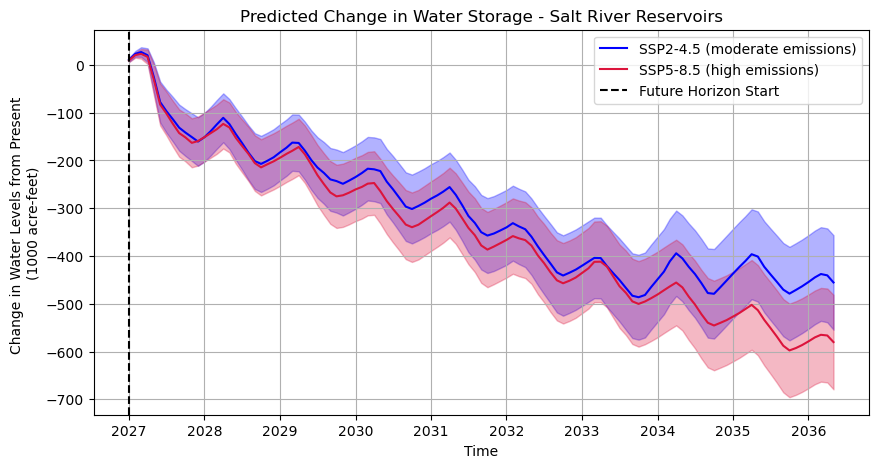

In [15]:

plt.figure(figsize=(10, 5))

plt.plot(
    pd.to_datetime(df_combined_245["Time"]), 
    df_combined_245["CumDiff_flow"], 
    label="SSP2-4.5 (moderate emissions)", 
    color="blue")
plt.fill_between(pd.to_datetime(df_combined_245['Time']),
                 df_combined_245['CumDiff_high'], df_combined_245['CumDiff_low'],
                 color='blue', alpha=0.3)
plt.plot(
    pd.to_datetime(df_combined_585["Time"]), 
    df_combined_585["CumDiff_flow"], 
    label="SSP5-8.5 (high emissions)", 
    color="crimson")
plt.fill_between(pd.to_datetime(df_combined_585['Time']),
                 df_combined_585['CumDiff_high'], df_combined_585['CumDiff_low'],
                 color='crimson', alpha=0.3)
plt.axvline(pd.to_datetime(df_combined_585["Time"].iloc[12]), color="black", linestyle="--", label="Future Horizon Start")
plt.title("Predicted Change in Water Storage - Salt River Reservoirs")
plt.ylabel("Change in Water Levels from Present \n(1000 acre-feet)")
plt.xlabel("Time")
plt.grid(True)
plt.legend()

plt.savefig(
    "../Output/PredictedCumulativeChange_SaltEB.png",
    dpi=300,
    bbox_inches="tight")

plt.show()